# Vulnerable record identification on 2011 UK Census dataset
This notebook provides the code to identify most vulnerable records for the 2011 UK Census dataset (https://www.ons.gov.uk/census/2011census/2011censusdata/censusmicrodata/microdatateachingfile). The list of most vulnerable records obtained from previous experiment is: `[565536, 566299, 569481, 266579, 562047, 563075, 558957, 371432, 409552, 511977]`.

Note: this notebook has been copied and adapted from the original "Achilles' heels: Vulnerable Record Identification in Synthetic Data" repository: https://github.com/computationalprivacy/MIA-synthetic/tree/main.

**Constraints related to the large dataset size:**
The dataset contains more than 500k samples, which results in very large computation time and large memory requirements. To deal with this problem, we only analyze the samples that have no duplicated, as the power of a privacy attack will be highly reduced for samples with duplicates. The script `scripts/identify_vulnerable_records_uk_census.py` allows to generate the distances for samples without duplcates in two different parts (first half of the samples is compared to the whole dataset, then the other part is compared to the whole dataset). This is useful to run the code on 2 different computers. For better time efficiency, this notebooks does not contain the distance calculation, but gather the results generated using the script, and analyze them to extract the 10 most vulnerable records.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# stdlib
import os
import sys
from pathlib import Path

# third party
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Achille's Heel
os.chdir('..')
sys.path.append('./libs/MIA-synthetic-main')
from src.data_prep import read_data, read_metadata, discretize_dataset, normalize_cont_cols

# custom
from tools.utils import load_pickle

## Load the original dataset
Let's load the original dataset. Even though it will not be directly useful, we will use it for sage checks when loading the precomputed distances.

In [3]:
PATH_TO_METADATA = './data/ah_repo/2011 Census Microdata Teaching Discretized.json'
PATH_TO_DATA = './data/census_header.csv'

meta_data_og, categorical_cols, continuous_cols = read_metadata(PATH_TO_METADATA)
df = read_data(PATH_TO_DATA, categorical_cols, continuous_cols)
df = discretize_dataset(df, categorical_cols)
df = normalize_cont_cols(df, meta_data_og, df_aux = df, types = ('Float', 'Integer'))
df.head()

,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,Health,Ethnic Group,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade
0,0,1,2,0,1,5,1,1,1,2,1,2,5,8,5,0,4
1,0,1,5,0,0,3,0,1,1,1,1,2,1,8,9,4,3
2,0,1,3,0,1,3,0,1,1,1,1,1,1,6,3,3,4
3,0,1,3,0,1,1,0,1,1,2,1,2,1,7,10,3,2
4,0,1,3,0,0,4,3,1,1,1,1,2,1,1,7,3,2


## Load the precomputed distances
In this case, the precomputed distances files are in a dedicated folder (which contains only these files) and each pickle file contains a dictionary with different keys. This allows an easy loading step.


In [4]:
ALL_DISTANCES = dict()
precomputed_distances_folder = Path('./generated/most_vulnerable_records')

# load all files in the folder
for file in tqdm(precomputed_distances_folder.iterdir()):
    subset_dict = load_pickle(file)
    ALL_DISTANCES.update(subset_dict)

68it [00:00, 198.25it/s]


Do a safe check to make sure that all distances have been computed.

In [5]:
print("Keys not computed:", len(set(df.drop_duplicates().index) - set(ALL_DISTANCES.keys())))
print("Keys not computed:", len(set(ALL_DISTANCES.keys()) - set(df.drop_duplicates().index)))

Keys not computed: 0
Keys not computed: 0


## Identify the vulnerable records
    
We'll now compute, for each record, the mean distance to its 5 closest neighbors. The records for which this distance is the largest are considered the vulnerable ones. 

In [6]:
K_NEIGHBORS = 5

mean_distance_top_5 = dict()
for target_id in ALL_DISTANCES.keys():
    mean_distance_top_5[target_id] = np.mean(ALL_DISTANCES[target_id][:K_NEIGHBORS])

Text(0.5, 1.0, 'Distribution of mean distances of 5 closest points')

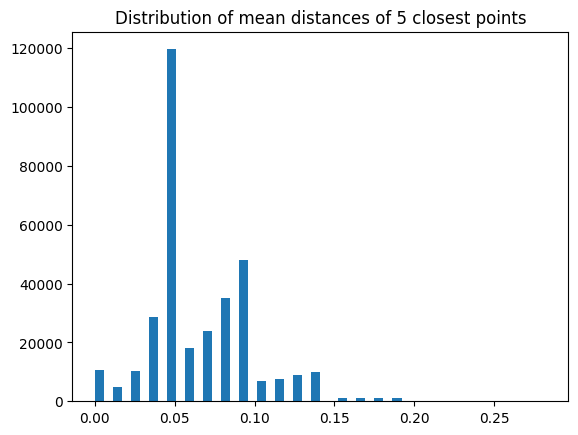

In [7]:
plt.figure()
plt.hist(mean_distance_top_5.values(), bins=50)
plt.title('Distribution of mean distances of 5 closest points')

We see that there a small amount of neighbords with a distance close to 0. This is due to the fact that we removed duplicates, and distance between categorical features is very small only where the neighbors have a lot of categories in common (in contrary to linear features, which have more possibilities to be close).

## Identify and analyze most vulnerable records
We select the top 10 vulnerable records. In this settings, the analysis focuses on the full dataset, containing a lot of duplicates.

In [8]:
# Identify 10 vulnerable records by taking the 10 records with the greatest value
sorted_key_vals = sorted(mean_distance_top_5.items(), key=lambda x:x[1], reverse = True)
vulnerable_records = [k[0] for k in sorted_key_vals[:10]]
print("Top 10 vulnerable records, ordered:", vulnerable_records)

Top 10 vulnerable records, ordered: [565536, 566299, 569481, 266579, 562047, 563075, 558957, 371432, 409552, 511977]


# Random records for comparison

In [9]:
# select 10 random records not in the vulnerable records
vulnerable_records = [565536, 566299, 569481, 266579, 562047, 563075, 558957, 371432, 409552, 511977]
np_rng = np.random.default_rng(42)
random_idx = np_rng.integers(0, len(df), 10)
random_idx = [idx for idx in random_idx if idx not in vulnerable_records]
print(random_idx)
print(len(random_idx))

[50849, 440954, 372936, 250047, 246706, 489178, 48966, 397319, 114785, 53656]
10


# Further analysis

Let's plot them to have a better understanding of their average distance.

Text(0.5, 1.0, 'Distribution of mean distances of 5 closest points for the top-10 most vulnerable records')

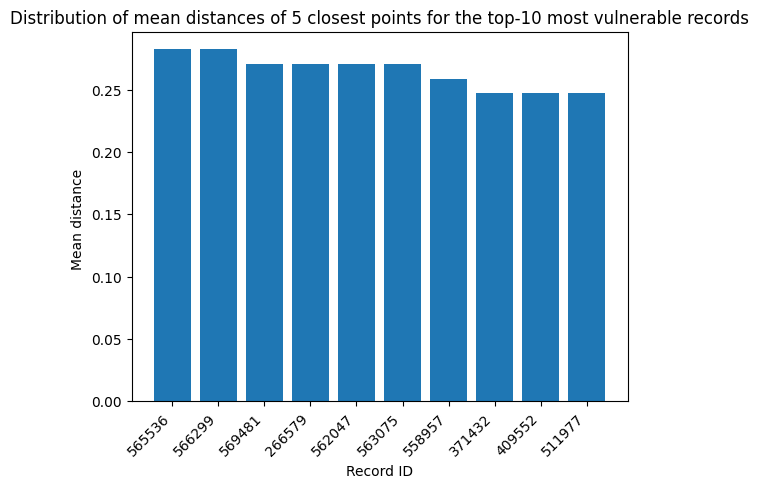

In [9]:
plt.figure()
# barplot of the 10 most vulnerable records, with their key and value
plt.bar([str(k) for k in vulnerable_records], [v for _, v in sorted_key_vals[:10]])
plt.title('Top 10 most vulnerable records average distance to 5 closest points')
plt.xlabel('Record ID')
plt.ylabel('Mean distance ')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of mean distances of 5 closest points for the top-10 most vulnerable records')

In [10]:
df.loc[vulnerable_records]

,Region,Residence Type,Family Composition,Population Base,Sex,Age,Marital Status,Student,Country of Birth,Health,Ethnic Group,Religion,Economic Activity,Occupation,Industry,Hours worked per week,Approximated Social Grade
565536,1,0,0,0,1,3,3,1,2,2,3,3,2,3,2,1,0
566299,0,0,0,0,0,3,3,0,2,3,3,6,4,5,12,2,0
569481,2,0,0,0,0,6,2,1,2,4,3,6,1,8,5,2,0
266579,3,1,3,0,1,5,4,0,1,5,2,9,6,2,12,0,2
562047,4,0,0,2,0,3,3,0,2,2,4,2,4,3,12,4,0
563075,1,0,0,0,0,5,1,1,2,1,2,8,1,8,9,4,0
558957,8,0,0,0,1,3,2,1,2,1,3,1,3,7,8,0,0
371432,1,1,1,0,1,2,2,0,2,3,2,9,4,6,4,3,2
409552,4,1,1,0,1,7,4,0,2,3,3,4,4,4,2,3,2
511977,6,1,3,0,1,3,4,0,1,5,1,1,4,8,5,4,2


We clearly see 3 groups (3 groups + record 558957 alone) of samples that have the exact same average distance to their nearest neighbors. Also, it's important to notice that the most vulnerable records are not duplicated. The exact same distance is likely due to two factors: 1) the distance is computed as the cosine similarity between two binary vectors. This means that two samples a,b can be at the exact same distance to a samples c if they are equal for all attributes except x_i, and that both don't have the same value as c for this attribute. For a simple example, suppose that a=[1,0,0], b=[0,1,0] and c=[0,0,1]. Then, the cross products computed in the cosine similarity for categorical variables (as presented in the paper) a·c=b·c=0 for both elements. 2) the presence of duplicate data: if a and b differe in one attribute from d and e, supposedly their nearest neighbors with d=e (duplicates), then the similarity of a and b to d and e is equal (0 in both case).  
  
The first factor is due to the distance definition, while the second one is due to the large amonunt of outliers in the UK census. By combining these two factors together, it does not seem to suprising to have such close results.

## Curiosity: what is the distance for the 1000 most vulnerable records?

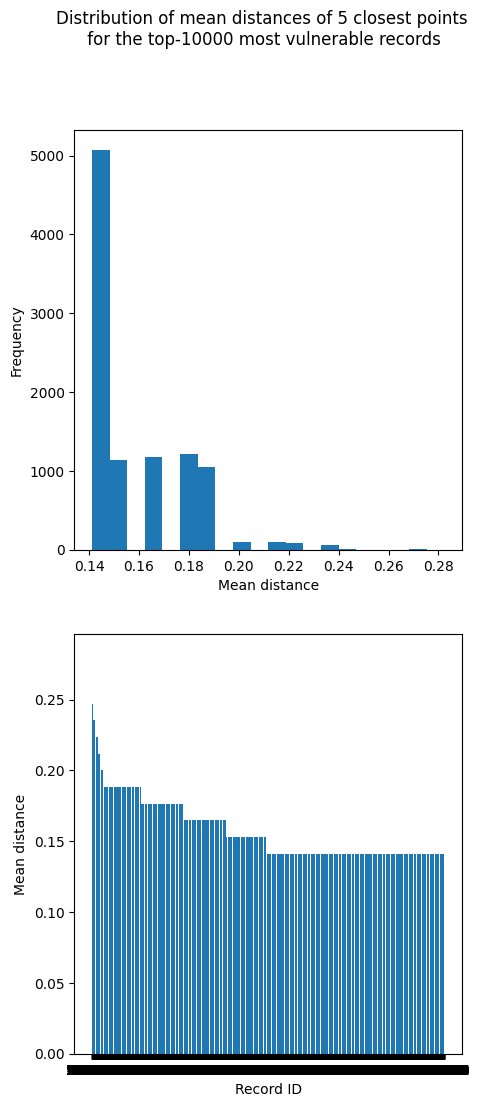

In [14]:
# lets investigate the distance for the 100 most vulnerable records
n_records_sup = 10000
sorted_key_vals = sorted(mean_distance_top_5.items(), key=lambda x:x[1], reverse = True)
vulnerable_records_sup = [k[0] for k in sorted_key_vals[:n_records_sup]]

fig, axs = plt.subplots(2, 1, figsize=(5, 12))

plt.suptitle('Distribution of mean distances of 5 closest points\n for the top-10000 most vulnerable records')
axs[0].hist([v for _, v in sorted_key_vals[:n_records_sup]], bins = 20)
axs[0].set_xlabel('Mean distance')
axs[0].set_ylabel('Frequency')

axs[1].bar([str(k) for k in vulnerable_records_sup], [v for _, v in sorted_key_vals[:n_records_sup]])
axs[1].set_xlabel('Record ID')
axs[1].set_ylabel('Mean distance')
plt.show()